In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler # Data preprocessing
from sklearn.model_selection import train_test_split # Data splitting
from sklearn.linear_model import LinearRegression # Machine learning model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Model evaluation metrics Validation

In [5]:
df = pd.read_csv('house_price_data 1.csv')
df.head()
df.fillna(df.mean(), inplace=True)
df.describe()
df.isnull().sum()

Area_sqft              0
Bedrooms               0
Bathrooms              0
Age_years              0
Distance_to_city_km    0
Garage                 0
Floors                 0
Price_USD              0
dtype: int64

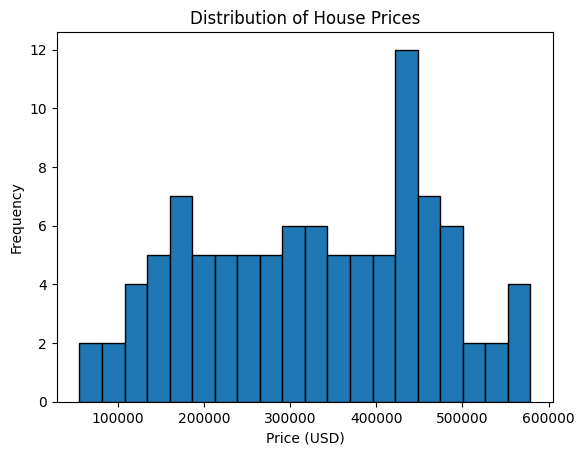

In [6]:
plt.Figure(figsize=(8, 4))
plt.hist(df['Price_USD'], bins=20, edgecolor='k')
plt.title('Distribution of House Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()


In [8]:
df.head()


,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors,Price_USD
0,3774,2,3,28,16.100000,1,3,446385
1,4107,4,2,17,23.300000,1,3,489543
2,1460,2,3,17,7.300000,0,1,185140
3,1894,2,3,1,14.676289,1,1,286522
4,1730,4,2,34,3.500000,0,2,212784


In [7]:
features = ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Distance_to_city_km', 'Garage', 'Floors']
X = df[features]
y = df['Price_USD']

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

X_test.head()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors
83,1375,3,3,15,24.6,0,1
53,2499,3,3,2,11.9,0,1
70,841,3,2,8,12.2,1,2
45,3347,3,3,28,15.3,1,1
44,4147,3,3,23,3.8,0,2


In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
y_pred = model.predict(X_test)
print(y_pred)

[144625.74508797 353955.23813483 156058.07200061 401107.14096177
 537718.4645628  142530.20601415 111309.10443326 258402.32081687
 132849.3434524  452958.23020758 544904.75351405 242210.31368303
 502788.79929934 507969.19900673 449188.78823832 224923.09468851
 228612.20523501 442467.32244799  96382.22509016 215985.15876461]


In [16]:
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')

Mean Absolute Error: 16392.590728301875


In [19]:
rmse = mean_squared_error(y_test, y_pred)
print(f'Root Mean Squared Error: {rmse}')

srmse= np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Square Root Mean Squared Error: {srmse}')

Root Mean Squared Error: 444438228.8245748
Square Root Mean Squared Error: 21081.70365090485


In [20]:
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')

R-squared: 0.9789071907782584


In [21]:
new_houses = pd.DataFrame({
    'Area_sqft'           : [1500, 3000],
    'Bedrooms'            : [2,    4   ],
    'Bathrooms'           : [1,    3   ],
    'Age_years'           : [10,   5   ],
    'Distance_to_city_km' : [15,   8   ],
    'Garage'              : [0,    1   ],
    'Floors'              : [1,    2   ]
})

new_houses

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors
0,1500,2,1,10,15,0,1
1,3000,4,3,5,8,1,2


In [22]:
predictions = model.predict(new_houses)
print(f'Predicted Prices for New Houses: {predictions}')

Predicted Prices for New Houses: [164593.78070182 464053.02023908]


In [23]:
print(model.intercept_)

7803.398315781786


In [25]:
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_})

print(coef_df)

               Feature   Coefficient
0            Area_sqft    120.030892
1             Bedrooms  15118.712620
2            Bathrooms  12256.817861
3            Age_years  -2414.452841
4  Distance_to_city_km  -3387.943565
5               Garage  19660.488238
6               Floors   9213.482874
